# Exploratory Data Analysis: ESI Triage Acuity Prediction

This notebook performs exploratory data analysis on the Triagegeist competition dataset. The goal is to provide the team with actionable findings before modeling begins.

**Questions this EDA answers:**

1. What does the data look like, and is it safe to merge?
2. Which features are post-triage leakage and must be excluded?
3. How is the target distributed, and what metrics should we use?
4. Does missingness carry clinical signal?
5. Which vital signs and clinical features best separate ESI levels?
6. Do categorical features (arrival mode, mental status, complaint system) have predictive value?
7. What does the chief complaint text look like — and is there a template shortcut?
8. How correlated are features, and which are redundant?
9. Are there signs that this dataset is synthetic?


## 1. Setup and Data Loading

### Goal

Load the required libraries and read all provided data files. This section also checks the size of each dataset to confirm that the files were loaded correctly.

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# Data path
DATA_DIR = Path("data")

# Load data files
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
complaints = pd.read_csv(DATA_DIR / "chief_complaints.csv")
history = pd.read_csv(DATA_DIR / "patient_history.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

# Basic file overview
file_overview = pd.DataFrame({
    "file": [
        "train",
        "test",
        "chief_complaints",
        "patient_history",
        "sample_submission"
    ],
    "rows": [
        train.shape[0],
        test.shape[0],
        complaints.shape[0],
        history.shape[0],
        sample_submission.shape[0]
    ],
    "columns": [
        train.shape[1],
        test.shape[1],
        complaints.shape[1],
        history.shape[1],
        sample_submission.shape[1]
    ]
})

file_overview

,file,rows,columns
0,train,80000,40
1,test,20000,37
2,chief_complaints,100000,3
3,patient_history,100000,26
4,sample_submission,20000,2


### Findings

All five data files were loaded successfully. The training set has 80,000 rows, the test set has 20,000 rows, and both auxiliary tables have 100,000 rows.

### Modeling implications

The auxiliary tables can be merged with train/test by `patient_id`, pending an ID uniqueness check.

## 2. Data Integrity and Merge Check

### Goal

Check whether `patient_id` is unique in each file, identify column differences between train and test, and verify that merging auxiliary tables does not duplicate rows.

In [6]:
# Check patient_id uniqueness in each file
files = {
    "train": train,
    "test": test,
    "chief_complaints": complaints,
    "patient_history": history,
    "sample_submission": sample_submission
}

id_check = []

for name, df in files.items():
    id_check.append({
        "file": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "patient_id_unique": df["patient_id"].is_unique,
        "duplicated_patient_id": df["patient_id"].duplicated().sum()
    })

id_check_df = pd.DataFrame(id_check)
id_check_df

,file,rows,columns,patient_id_unique,duplicated_patient_id
0,train,80000,40,True,0
1,test,20000,37,True,0
2,chief_complaints,100000,3,True,0
3,patient_history,100000,26,True,0
4,sample_submission,20000,2,True,0


In [7]:
# Compare columns between train and test
train_only_cols = sorted(set(train.columns) - set(test.columns))
test_only_cols = sorted(set(test.columns) - set(train.columns))

print("Columns only in train:")
print(train_only_cols)

print("\nColumns only in test:")
print(test_only_cols)

Columns only in train:
['disposition', 'ed_los_hours', 'triage_acuity']

Columns only in test:
[]


In [9]:
# Merge train and test with chief complaints and patient history
train_merged = (
    train
    .merge(complaints, on="patient_id", how="left")
    .merge(history, on="patient_id", how="left")
)

test_merged = (
    test
    .merge(complaints, on="patient_id", how="left")
    .merge(history, on="patient_id", how="left")
)

merge_check = pd.DataFrame({
    "dataset": ["train", "test"],
    "rows_before_merge": [train.shape[0], test.shape[0]],
    "cols_before_merge": [train.shape[1], test.shape[1]],
    "rows_after_merge": [train_merged.shape[0], test_merged.shape[0]],
    "cols_after_merge": [train_merged.shape[1], test_merged.shape[1]]
})

merge_check

,dataset,rows_before_merge,cols_before_merge,rows_after_merge,cols_after_merge
0,train,80000,40,80000,67
1,test,20000,37,20000,64


**Findings:** All files have unique `patient_id`; merging complaints and history adds 27 columns without duplicating rows. Train has three columns absent from test: `triage_acuity` (target), `disposition`, and `ed_los_hours`. The latter two are potential leakage and require audit before modeling.

The merge creates duplicated `chief_complaint_system` columns because this field appears in both the main table and the complaints table. Since the values match, we keep one copy and drop the duplicate.

## 3. Identify Target Leakage

### Goal

Identify variables that would not be available at triage time but may strongly reveal the target.

In [10]:
availability_table = pd.DataFrame([
    {
        "feature": "triage_acuity",
        "role": "target",
        "available_at_triage": "No",
        "decision": "target only"
    },
    {
        "feature": "disposition",
        "role": "post-triage outcome",
        "available_at_triage": "No",
        "decision": "exclude"
    },
    {
        "feature": "ed_los_hours",
        "role": "post-triage outcome",
        "available_at_triage": "No",
        "decision": "exclude"
    },
    {
        "feature": "news2_score",
        "role": "clinical score",
        "available_at_triage": "Likely yes, if computed from intake vitals",
        "decision": "keep, but ablate"
    },
    {
        "feature": "site_id",
        "role": "operational context",
        "available_at_triage": "Yes",
        "decision": "use cautiously"
    },
    {
        "feature": "triage_nurse_id",
        "role": "provider / workflow",
        "available_at_triage": "Yes",
        "decision": "audit or ablate"
    }
])

availability_table

,feature,role,available_at_triage,decision
0,triage_acuity,target,No,target only
1,disposition,post-triage outcome,No,exclude
2,ed_los_hours,post-triage outcome,No,exclude
3,news2_score,clinical score,"Likely yes, if computed from intake vitals","keep, but ablate"
4,site_id,operational context,Yes,use cautiously
5,triage_nurse_id,provider / workflow,Yes,audit or ablate


In [11]:
ed_los_summary = (
    train_merged
    .groupby("triage_acuity")["ed_los_hours"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

ed_los_corr = train_merged["ed_los_hours"].corr(train_merged["triage_acuity"])

print(f"Correlation between ed_los_hours and triage_acuity: {ed_los_corr:.4f}")

ed_los_summary

Correlation between ed_los_hours and triage_acuity: -0.7567


,count,mean,median,std,min,max
triage_acuity,,,,,,
1,3222,7.96,7.96,2.95,0.07,17.51
2,13439,6.04,6.02,2.47,0.00,15.14
3,28921,3.98,3.99,1.49,0.00,10.00
4,23020,2.01,2.00,0.96,0.00,6.15
5,11398,1.01,1.00,0.48,0.00,2.86


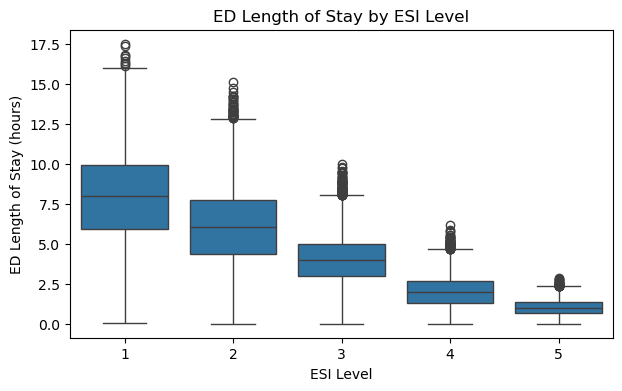

In [12]:
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=train_merged,
    x="triage_acuity",
    y="ed_los_hours"
)

plt.title("ED Length of Stay by ESI Level")
plt.xlabel("ESI Level")
plt.ylabel("ED Length of Stay (hours)")
plt.show()

In [13]:
disposition_by_esi = pd.crosstab(
    train_merged["triage_acuity"],
    train_merged["disposition"],
    normalize="index"
) * 100

disposition_by_esi.round(2)

disposition,admitted,deceased,discharged,lama,lwbs,observation,transferred
triage_acuity,,,,,,,
1,71.76,8.29,2.08,0.00,0.00,3.04,14.84
2,65.14,1.07,12.21,0.93,0.95,7.96,11.73
3,38.20,0.00,37.58,3.86,4.08,8.15,8.13
4,9.85,0.00,72.15,5.22,6.80,3.01,2.97
5,1.92,0.00,86.36,2.82,6.87,1.04,1.00


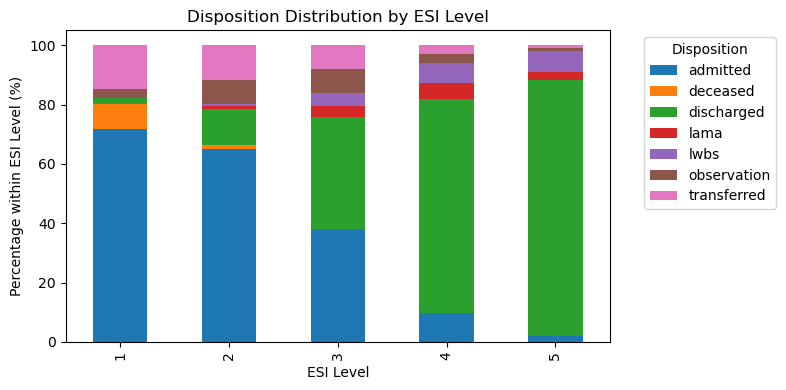

In [14]:
disposition_by_esi.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4)
)

plt.title("Disposition Distribution by ESI Level")
plt.xlabel("ESI Level")
plt.ylabel("Percentage within ESI Level (%)")
plt.legend(title="Disposition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [15]:
TARGET = "triage_acuity"

ID_COLS = ["patient_id"]

LEAKAGE_COLS = [
    "disposition",
    "ed_los_hours"
]

EXCLUDE_COLS = ID_COLS + LEAKAGE_COLS + [TARGET]

EXCLUDE_COLS

['patient_id', 'disposition', 'ed_los_hours', 'triage_acuity']

**Findings:** `ed_los_hours` and `disposition` are leakage features. ED stay is strongly associated with ESI (`r = -0.7567`; median 7.96h for ESI-1 vs 1.00h for ESI-5), and disposition shifts from admitted/transferred/deceased in high-acuity cases to mostly discharged in low-acuity cases. Both are post-triage outcomes, so they must be excluded from model features.

## 4. Understand the ESI Target

### Goal

Understand the class distribution of `triage_acuity` and decide which evaluation metrics are clinically appropriate.

In [16]:
target_dist = (
    train_merged["triage_acuity"]
    .value_counts()
    .sort_index()
    .rename_axis("triage_acuity")
    .reset_index(name="count")
)

target_dist["percentage"] = (
    target_dist["count"] / len(train_merged) * 100
).round(2)

esi_meaning = {
    1: "most urgent",
    2: "high acuity",
    3: "moderate",
    4: "low acuity",
    5: "least urgent"
}

target_dist["clinical_meaning"] = target_dist["triage_acuity"].map(esi_meaning)

target_dist

,triage_acuity,count,percentage,clinical_meaning
0,1,3222,4.03,most urgent
1,2,13439,16.80,high acuity
2,3,28921,36.15,moderate
3,4,23020,28.78,low acuity
4,5,11398,14.25,least urgent


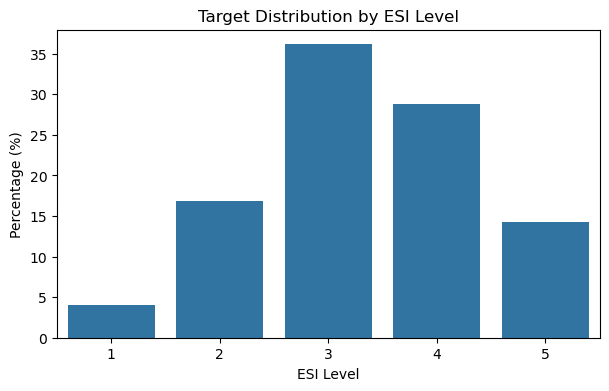

In [17]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=target_dist,
    x="triage_acuity",
    y="percentage"
)

plt.title("Target Distribution by ESI Level")
plt.xlabel("ESI Level")
plt.ylabel("Percentage (%)")
plt.show()

In [18]:
high_acuity_summary = pd.DataFrame({
    "group": ["high_acuity_ESI_1_2", "lower_acuity_ESI_3_4_5"],
    "count": [
        train_merged["triage_acuity"].isin([1, 2]).sum(),
        train_merged["triage_acuity"].isin([3, 4, 5]).sum()
    ]
})

high_acuity_summary["percentage"] = (
    high_acuity_summary["count"] / len(train_merged) * 100
).round(2)

high_acuity_summary

,group,count,percentage
0,high_acuity_ESI_1_2,16661,20.83
1,lower_acuity_ESI_3_4_5,63339,79.17


In [20]:
metric_table = pd.DataFrame([
    {
        "metric": "Accuracy",
        "purpose": "Overall baseline",
        "reason": "Simple but insufficient"
    },
    {
        "metric": "Macro F1",
        "purpose": "Class-balanced performance",
        "reason": "ESI-1 is rare"
    },
    {
        "metric": "Weighted Kappa",
        "purpose": "Ordinal performance",
        "reason": "ESI levels are ordered"
    },
    {
        "metric": "ESI-1 / ESI-2 Recall",
        "purpose": "High-acuity detection",
        "reason": "Missed urgent patients are risky"
    },
    {
        "metric": "Dangerous Undertriage Rate",
        "purpose": "Clinical safety",
        "reason": "ESI 1-2 predicted as ESI 3-5"
    }
])

metric_table

,metric,purpose,reason
0,Accuracy,Overall baseline,Simple but insufficient
1,Macro F1,Class-balanced performance,ESI-1 is rare
2,Weighted Kappa,Ordinal performance,ESI levels are ordered
3,ESI-1 / ESI-2 Recall,High-acuity detection,Missed urgent patients are risky
4,Dangerous Undertriage Rate,Clinical safety,ESI 1-2 predicted as ESI 3-5


**Findings:** ESI-1 is rare, accounting for only 4.03% of the training data. ESI-3 and ESI-4 dominate the dataset, together accounting for 64.93%. High-acuity cases (ESI 1-2) make up 20.83%, while lower-acuity cases (ESI 3-5) make up 79.17%.

**Interpretation:** This is an ordinal and clinically asymmetric classification problem. A model may achieve high overall accuracy while still missing rare but urgent ESI-1/2 patients.

**Modeling implications:** Do not rely on accuracy alone. Later evaluation should include Macro F1, Weighted Kappa, ESI-1/2 recall, and Dangerous Undertriage Rate.

## 5. Examine Missingness Patterns

### Goal

Check whether missing values are random data quality issues or structured signals related to triage workflow.

In [21]:
# Overall missingness in merged training data
missing_overview = pd.DataFrame({
    "missing_count": train_merged.isna().sum(),
    "missing_percentage": train_merged.isna().mean() * 100
})

missing_overview = (
    missing_overview
    .query("missing_count > 0")
    .sort_values("missing_percentage", ascending=False)
    .round(2)
)

missing_overview

,missing_count,missing_percentage
systolic_bp,4146,5.18
diastolic_bp,4146,5.18
mean_arterial_pressure,4146,5.18
pulse_pressure,4146,5.18
shock_index,4146,5.18
respiratory_rate,3067,3.83
temperature_c,574,0.72


In [27]:
raw_missing_cols = [
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "respiratory_rate",
    "temperature_c",
    "spo2",
    "pain_score",
    "gcs_total",
    "news2_score"
]

raw_missing_cols = [col for col in raw_missing_cols if col in train_merged.columns]

missing_overview = pd.DataFrame({
    "missing_count": train_merged[raw_missing_cols].isna().sum(),
    "missing_percentage": train_merged[raw_missing_cols].isna().mean() * 100
}).query("missing_count > 0").sort_values("missing_percentage", ascending=False).round(2)

missing_overview

,missing_count,missing_percentage
systolic_bp,4146,5.18
diastolic_bp,4146,5.18
respiratory_rate,3067,3.83
temperature_c,574,0.72


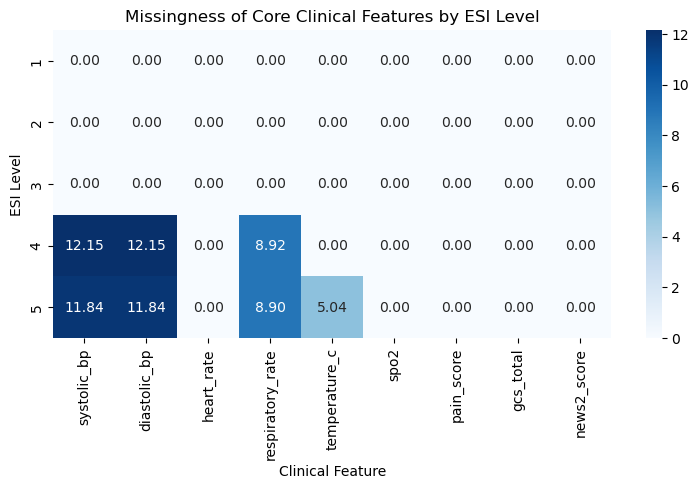

In [28]:
plt.figure(figsize=(9, 4))

sns.heatmap(
    missing_by_esi,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Missingness of Core Clinical Features by ESI Level")
plt.xlabel("Clinical Feature")
plt.ylabel("ESI Level")
plt.show()

In [29]:
# Check special pain score code
train_merged["pain_score_minus_one"] = train_merged["pain_score"] == -1

pain_minus_one_by_esi = (
    train_merged
    .groupby("triage_acuity")["pain_score_minus_one"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="pain_score_minus_one_percentage")
)

pain_minus_one_by_esi

,triage_acuity,pain_score_minus_one_percentage
0,1,0.00
1,2,0.00
2,3,17.95
3,4,17.44
4,5,17.11


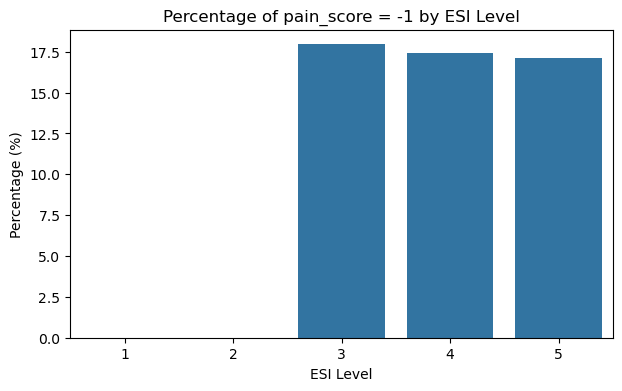

In [30]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=pain_minus_one_by_esi,
    x="triage_acuity",
    y="pain_score_minus_one_percentage"
)

plt.title("Percentage of pain_score = -1 by ESI Level")
plt.xlabel("ESI Level")
plt.ylabel("Percentage (%)")
plt.show()

In [31]:
# Create cleaned pain score and missing vital count
train_merged["pain_score_clean"] = train_merged["pain_score"].replace(-1, np.nan)

train_merged["missing_vital_count"] = (
    train_merged[VITAL_COLS]
    .isna()
    .sum(axis=1)
)

missing_vital_summary = (
    train_merged
    .groupby("triage_acuity")["missing_vital_count"]
    .agg(["count", "mean", "median", "max"])
    .round(3)
)

missing_vital_summary

,count,mean,median,max
triage_acuity,,,,
1,3222,0.000,0.0,0
2,13439,0.000,0.0,0
3,28921,0.000,0.0,0
4,23020,0.332,0.0,3
5,11398,0.376,0.0,4


In [33]:
# Create cleaned pain score and missingness features
train_merged["pain_score_missing_code"] = train_merged["pain_score"] == -1
train_merged["pain_score_clean"] = train_merged["pain_score"].replace(-1, np.nan)

train_merged["missing_vital_count"] = (
    train_merged[raw_missing_cols]
    .isna()
    .sum(axis=1)
)

**Findings:** Missingness is concentrated in lower-acuity cases. ESI 1-3 have complete core vital signs, while ESI 4-5 show missing blood pressure, respiratory rate, and temperature values. `pain_score = -1` appears only in ESI 3-5, around 17-18%, and never in ESI 1-2.

**Interpretation:** Missingness is not random. It likely reflects triage workflow: higher-acuity patients receive complete documentation, while lower-acuity patients may have some measurements omitted or coded as not assessed.

**Modeling implications:** Do not drop missing rows. Add missing indicators, create `missing_vital_count`, and treat `pain_score = -1` as a special missing code rather than a true numeric pain value.

## 6. Analyze Vital Signs by ESI Level

### Goal

Check whether core vital signs and clinical scores differ across ESI levels, and identify which numerical features are likely useful for prediction.

In [34]:
# Use cleaned pain score from the previous missingness section
# If this column does not exist yet, create it here
train_merged["pain_score_clean"] = train_merged["pain_score"].replace(-1, np.nan)

# Core numerical clinical features
clinical_num_cols = [
    "age",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "respiratory_rate",
    "temperature_c",
    "spo2",
    "gcs_total",
    "news2_score",
    "pain_score_clean"
]

clinical_num_cols = [col for col in clinical_num_cols if col in train_merged.columns]

clinical_num_cols

['age',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'respiratory_rate',
 'temperature_c',
 'spo2',
 'gcs_total',
 'news2_score',
 'pain_score_clean']

In [35]:
# Median clinical values by ESI level
vital_median_by_esi = (
    train_merged
    .groupby("triage_acuity")[clinical_num_cols]
    .median()
    .round(2)
)

vital_median_by_esi

,age,systolic_bp,diastolic_bp,heart_rate,respiratory_rate,temperature_c,spo2,gcs_total,news2_score,pain_score_clean
triage_acuity,,,,,,,,,,
1,49.0,82.6,52.15,119.2,28.0,38.9,85.9,6.5,14.0,9.0
2,48.0,100.4,63.30,108.7,23.0,38.5,92.0,12.0,10.0,8.0
3,48.0,126.0,76.90,93.0,18.0,37.7,96.0,15.0,2.0,6.0
4,48.0,132.0,80.00,84.1,16.0,37.2,98.0,15.0,0.0,4.0
5,48.0,128.1,78.80,76.8,15.0,36.9,99.0,15.0,0.0,2.0


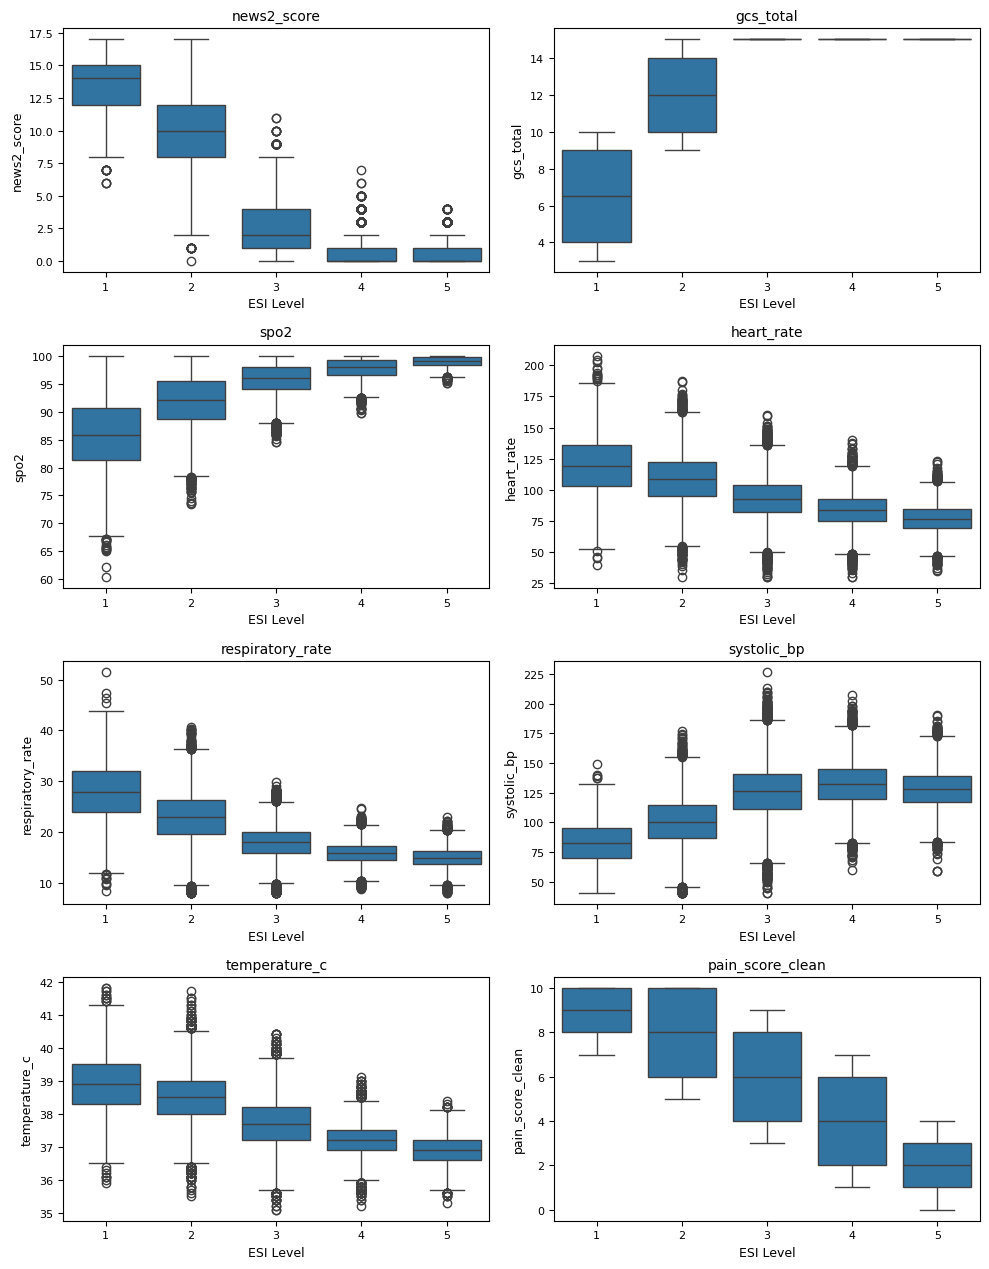

In [36]:
# Compact boxplots for core clinical features
core_plot_cols = [
    "news2_score",
    "gcs_total",
    "spo2",
    "heart_rate",
    "respiratory_rate",
    "systolic_bp",
    "temperature_c",
    "pain_score_clean"
]

core_plot_cols = [col for col in core_plot_cols if col in train_merged.columns]

n_cols = 2
n_rows = int(np.ceil(len(core_plot_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10, 3.2 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(core_plot_cols):
    sns.boxplot(
        data=train_merged,
        x="triage_acuity",
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("ESI Level", fontsize=9)
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].tick_params(axis="both", labelsize=8)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [37]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer

X_mi = train_merged[clinical_num_cols]
y_mi = train_merged["triage_acuity"]

# Impute missing values before calculating mutual information
imputer = SimpleImputer(strategy="median")
X_mi_imputed = imputer.fit_transform(X_mi)

mi_scores = mutual_info_classif(
    X_mi_imputed,
    y_mi,
    random_state=42
)

mi_results = (
    pd.DataFrame({
        "feature": clinical_num_cols,
        "mutual_information": mi_scores
    })
    .sort_values("mutual_information", ascending=False)
    .round(4)
)

mi_results

,feature,mutual_information
8,news2_score,0.6753
7,gcs_total,0.4785
9,pain_score_clean,0.4402
6,spo2,0.3568
4,respiratory_rate,0.3501
5,temperature_c,0.3012
1,systolic_bp,0.2308
3,heart_rate,0.2127
2,diastolic_bp,0.1943
0,age,0.0000


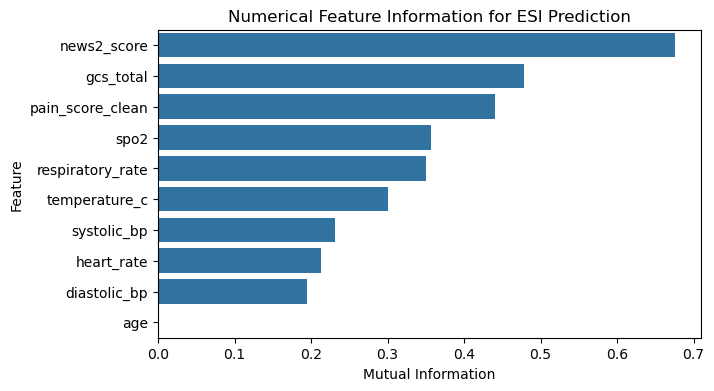

In [38]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=mi_results,
    x="mutual_information",
    y="feature"
)

plt.title("Numerical Feature Information for ESI Prediction")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.show()

**Findings:** Core clinical variables show clear separation across ESI levels. High-acuity patients have higher NEWS2, lower GCS, lower SpO2, higher respiratory rate, higher heart rate, lower blood pressure, higher temperature, and higher pain scores. Mutual information ranks `news2_score`, `gcs_total`, `pain_score_clean`, `spo2`, and `respiratory_rate` as the strongest numerical predictors, while `age` contributes almost no information.

**Interpretation:** The target is strongly aligned with physiological severity rather than demographics. The strongest signals are clinically plausible: NEWS2 summarizes acute deterioration risk, GCS captures neurological status, SpO2 and respiratory rate capture respiratory compromise, and cleaned pain score captures symptom severity.

**Modeling implications:** Retain core vital signs and cleaned pain score as structured predictors. Use `pain_score_clean` instead of raw `pain_score`. Keep `news2_score` initially, but later run an ablation because it overlaps with raw vital signs.

## 7. Convert Vitals into Clinical Risk Flags

### Goal

Create clinically interpretable risk flags from vital signs and check whether these flags concentrate in high-acuity ESI levels.

In [39]:
# Create clinically interpretable risk flags
train_merged["high_news2"] = train_merged["news2_score"] >= 7

train_merged["low_gcs"] = train_merged["gcs_total"] < 15
train_merged["very_low_gcs"] = train_merged["gcs_total"] <= 8

train_merged["low_spo2"] = train_merged["spo2"] < 92
train_merged["very_low_spo2"] = train_merged["spo2"] < 90

train_merged["tachycardia"] = train_merged["heart_rate"] > 100
train_merged["bradycardia"] = train_merged["heart_rate"] < 50

train_merged["tachypnea"] = train_merged["respiratory_rate"] > 20

train_merged["hypotension"] = train_merged["systolic_bp"] < 90

train_merged["fever"] = train_merged["temperature_c"] >= 38
train_merged["hypothermia"] = train_merged["temperature_c"] < 35

train_merged["severe_pain"] = train_merged["pain_score_clean"] >= 7

clinical_flag_cols = [
    "high_news2",
    "low_gcs",
    "very_low_gcs",
    "low_spo2",
    "very_low_spo2",
    "tachycardia",
    "bradycardia",
    "tachypnea",
    "hypotension",
    "fever",
    "hypothermia",
    "severe_pain"
]

clinical_flag_cols

['high_news2',
 'low_gcs',
 'very_low_gcs',
 'low_spo2',
 'very_low_spo2',
 'tachycardia',
 'bradycardia',
 'tachypnea',
 'hypotension',
 'fever',
 'hypothermia',
 'severe_pain']

In [40]:
# Percentage of each clinical risk flag by ESI level
clinical_flags_by_esi = (
    train_merged
    .groupby("triage_acuity")[clinical_flag_cols]
    .mean()
    .mul(100)
    .round(2)
)

clinical_flags_by_esi

,high_news2,low_gcs,very_low_gcs,low_spo2,very_low_spo2,tachycardia,bradycardia,tachypnea,hypotension,fever,hypothermia,severe_pain
triage_acuity,,,,,,,,,,,,
1,99.91,100.00,74.52,80.48,71.57,78.21,0.09,90.38,65.39,86.28,0.0,100.00
2,90.46,85.58,0.00,49.45,34.21,66.87,0.18,71.87,30.52,75.79,0.0,71.55
3,2.37,0.00,0.00,8.78,2.16,33.04,0.37,24.72,4.78,35.94,0.0,35.40
4,0.00,0.00,0.00,0.11,0.01,11.37,0.46,2.09,0.89,6.47,0.0,11.72
5,0.00,0.00,0.00,0.00,0.00,1.93,0.65,0.68,0.84,0.42,0.0,0.00


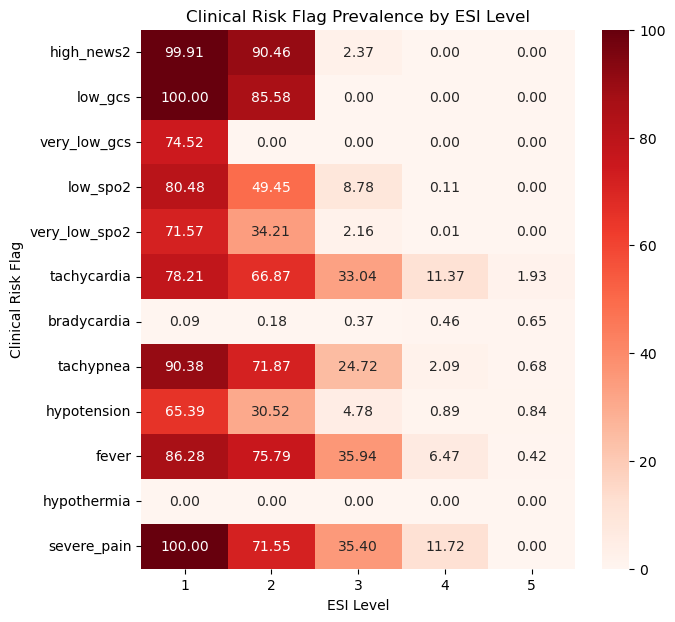

In [42]:
plt.figure(figsize=(7, 7))

sns.heatmap(
    clinical_flags_by_esi.T,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)

plt.title("Clinical Risk Flag Prevalence by ESI Level")
plt.xlabel("ESI Level")
plt.ylabel("Clinical Risk Flag")
plt.show()

**Findings:** Clinical risk flags are strongly concentrated in high-acuity patients. ESI-1 has extremely high prevalence of `high_news2` (99.91%), `low_gcs` (100%), `very_low_gcs` (74.52%), `low_spo2` (80.48%), `tachypnea` (90.38%), `fever` (86.28%), and `severe_pain` (100%). Most of these flags drop sharply in ESI 3-5.

**Interpretation:** These flags convert raw vitals into clinically meaningful risk signals. The sharp separation suggests that ESI labels are strongly aligned with physiological danger signs, though the near-perfect prevalence of some flags in ESI-1 may indicate rule-like structure in the dataset.

**Modeling implications:** Keep these flags as interpretable engineered features, but later test whether they add value beyond raw vitals and NEWS2.

## 8. Analyze Categorical Triage Signals

### Goal

Check whether categorical intake variables show meaningful patterns across ESI levels, and identify which categorical features are likely useful for prediction or audit.

In [43]:
# Candidate categorical features for EDA
categorical_cols = [
    "arrival_mode",
    "mental_status_triage",
    "chief_complaint_system",
    "sex",
    "age_group",
    "language",
    "insurance_type",
    "site_id",
    "triage_nurse_id"
]

categorical_cols = [col for col in categorical_cols if col in train_merged.columns]

# Basic summary of categorical features
cat_summary = pd.DataFrame({
    "feature": categorical_cols,
    "n_unique": [train_merged[col].nunique(dropna=False) for col in categorical_cols],
    "missing_percentage": [
        train_merged[col].isna().mean() * 100 for col in categorical_cols
    ]
}).round(2)

cat_summary

,feature,n_unique,missing_percentage
0,arrival_mode,6,0.0
1,mental_status_triage,5,0.0
2,sex,3,0.0
3,age_group,4,0.0
4,language,8,0.0
5,insurance_type,5,0.0
6,site_id,5,0.0
7,triage_nurse_id,50,0.0


In [44]:
def normalized_crosstab_by_esi(df, column, target="triage_acuity"):
    """Return percentage distribution of ESI levels within each category."""
    table = pd.crosstab(
        df[column],
        df[target],
        normalize="index"
    ) * 100
    
    return table.round(2)

In [45]:
mental_status_esi = normalized_crosstab_by_esi(
    train_merged,
    "mental_status_triage"
)

mental_status_esi

triage_acuity,1,2,3,4,5
mental_status_triage,,,,,
agitated,5.53,34.45,39.17,18.90,1.94
alert,0.08,2.96,34.22,39.85,22.88
confused,1.06,27.86,51.56,16.20,3.32
drowsy,8.72,44.53,31.30,12.87,2.57
unresponsive,42.63,44.59,12.78,0.00,0.00


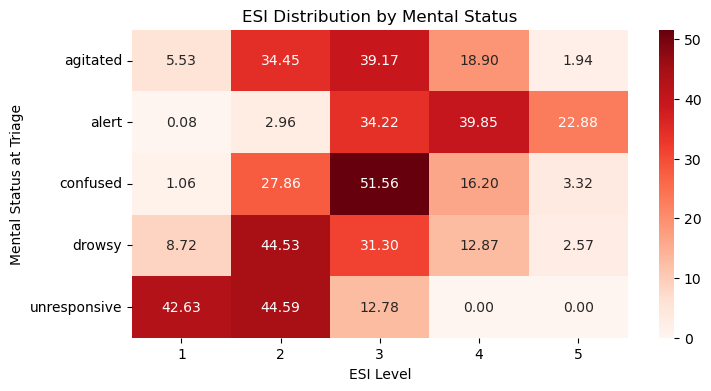

In [46]:
plt.figure(figsize=(8, 4))

sns.heatmap(
    mental_status_esi,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)

plt.title("ESI Distribution by Mental Status")
plt.xlabel("ESI Level")
plt.ylabel("Mental Status at Triage")
plt.show()

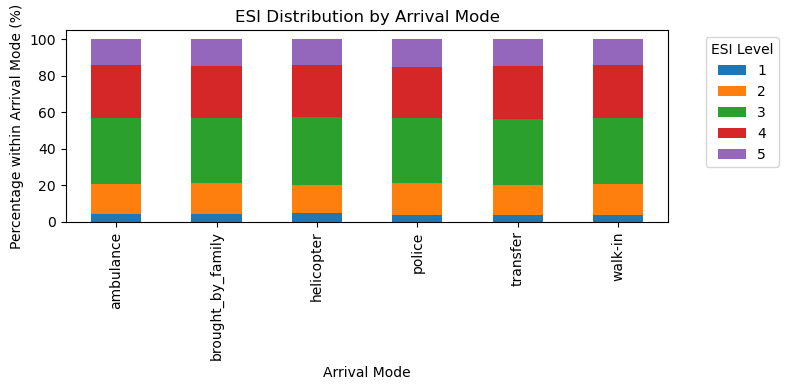

In [47]:
arrival_mode_esi = normalized_crosstab_by_esi(
    train_merged,
    "arrival_mode"
)

arrival_mode_esi

arrival_mode_esi.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4)
)

plt.title("ESI Distribution by Arrival Mode")
plt.xlabel("Arrival Mode")
plt.ylabel("Percentage within Arrival Mode (%)")
plt.legend(title="ESI Level", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [53]:
# Fix duplicated chief_complaint_system columns created during merge
if "chief_complaint_system_x" in train_merged.columns and "chief_complaint_system_y" in train_merged.columns:
    match_rate = (
        train_merged["chief_complaint_system_x"]
        == train_merged["chief_complaint_system_y"]
    ).mean()
    
    print("chief_complaint_system match rate:", match_rate)
    
    train_merged["chief_complaint_system"] = train_merged["chief_complaint_system_x"]
    train_merged = train_merged.drop(
        columns=["chief_complaint_system_x", "chief_complaint_system_y"]
    )

if "chief_complaint_system_x" in test_merged.columns and "chief_complaint_system_y" in test_merged.columns:
    test_merged["chief_complaint_system"] = test_merged["chief_complaint_system_x"]
    test_merged = test_merged.drop(
        columns=["chief_complaint_system_x", "chief_complaint_system_y"]
    )

[col for col in train_merged.columns if "complaint" in col.lower()]

['chief_complaint_raw', 'chief_complaint_system']

In [54]:
top_complaint_systems = (
    train_merged["chief_complaint_system"]
    .value_counts()
    .head(10)
    .index
)

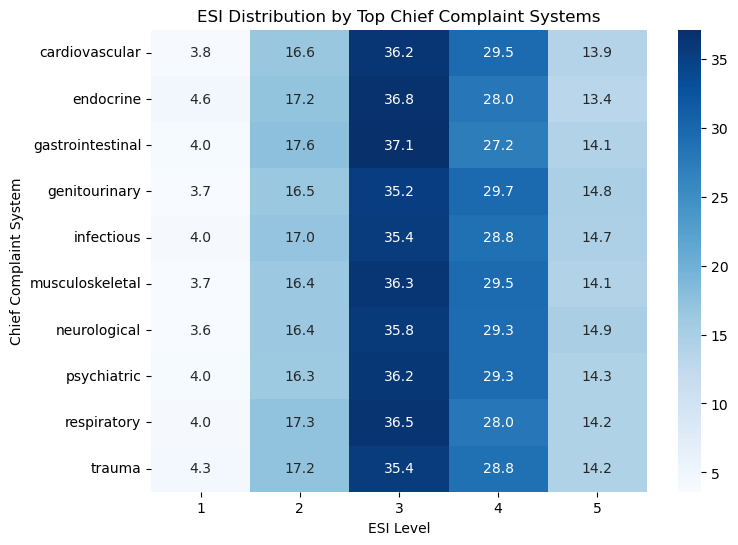

In [55]:
top_complaint_systems = (
    train_merged["chief_complaint_system"]
    .value_counts()
    .head(10)
    .index
)

complaint_system_top = train_merged[
    train_merged["chief_complaint_system"].isin(top_complaint_systems)
]

complaint_system_top_esi = normalized_crosstab_by_esi(
    complaint_system_top,
    "chief_complaint_system"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    complaint_system_top_esi,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("ESI Distribution by Top Chief Complaint Systems")
plt.xlabel("ESI Level")
plt.ylabel("Chief Complaint System")
plt.show()

In [56]:
operational_cols = [
    col for col in ["site_id", "triage_nurse_id"]
    if col in train_merged.columns
]

operational_summary = pd.DataFrame({
    "feature": operational_cols,
    "n_unique": [
        train_merged[col].nunique(dropna=False)
        for col in operational_cols
    ],
    "largest_category_percentage": [
        train_merged[col].value_counts(normalize=True, dropna=False).iloc[0] * 100
        for col in operational_cols
    ]
}).round(2)

operational_summary

,feature,n_unique,largest_category_percentage
0,site_id,5,20.26
1,triage_nurse_id,50,2.10


**Findings:** `mental_status_triage` shows a clear relationship with ESI level. Unresponsive patients are mostly high-acuity: 42.63% ESI-1 and 44.59% ESI-2. Alert patients are mostly lower-acuity, with 39.85% ESI-4 and 22.88% ESI-5. In contrast, `arrival_mode` has almost identical ESI distributions across categories, suggesting weak predictive value. Top `chief_complaint_system` categories also show very similar ESI distributions.

**Interpretation:** Mental status is a meaningful triage signal, while arrival mode and broad complaint system appear less discriminative in this dataset. Operational variables require caution: `site_id` has 5 categories, and `triage_nurse_id` has 50 categories, so they may encode hospital or provider practice rather than patient severity.

**Modeling implications:** Keep `mental_status_triage` as an important categorical predictor. Use `arrival_mode` and `chief_complaint_system` as secondary features, but do not expect them to drive performance. Treat `site_id` and `triage_nurse_id` as audit or ablation features rather than core clinical predictors.

## 9. Analyze Chief Complaint Text

### Goal

Check whether chief complaint text contains useful clinical signal, and whether repeated complaint templates may create shortcut risk.

In [57]:
# Chief complaint text column
TEXT_COL = "chief_complaint_raw"

# Basic text availability and length
text_summary = pd.DataFrame({
    "metric": [
        "rows",
        "missing_text_count",
        "missing_text_percentage",
        "unique_text_count",
        "duplicate_text_percentage",
        "mean_text_length",
        "median_text_length"
    ],
    "value": [
        len(train_merged),
        train_merged[TEXT_COL].isna().sum(),
        train_merged[TEXT_COL].isna().mean() * 100,
        train_merged[TEXT_COL].nunique(dropna=True),
        (1 - train_merged[TEXT_COL].nunique(dropna=True) / len(train_merged)) * 100,
        train_merged[TEXT_COL].fillna("").str.len().mean(),
        train_merged[TEXT_COL].fillna("").str.len().median()
    ]
})

text_summary["value"] = text_summary["value"].round(2)
text_summary

,metric,value
0,rows,80000.00
1,missing_text_count,0.00
2,missing_text_percentage,0.00
3,unique_text_count,4949.00
4,duplicate_text_percentage,93.81
5,mean_text_length,39.67
6,median_text_length,39.00


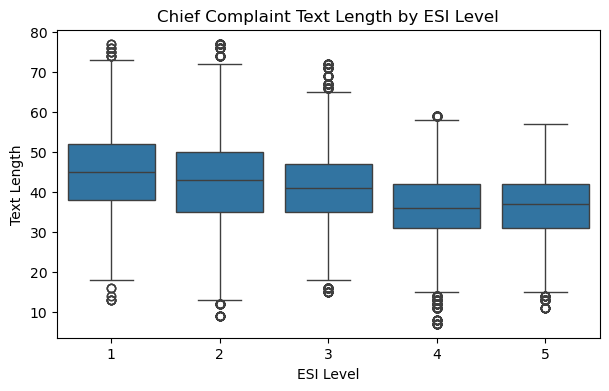

In [58]:
# Create text length feature
train_merged["complaint_text_length"] = (
    train_merged[TEXT_COL]
    .fillna("")
    .str.len()
)

text_length_by_esi = (
    train_merged
    .groupby("triage_acuity")["complaint_text_length"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

text_length_by_esi

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=train_merged,
    x="triage_acuity",
    y="complaint_text_length"
)

plt.title("Chief Complaint Text Length by ESI Level")
plt.xlabel("ESI Level")
plt.ylabel("Text Length")
plt.show()

In [59]:
# Most frequent raw chief complaints
top_complaints = (
    train_merged[TEXT_COL]
    .value_counts()
    .head(20)
    .reset_index()
)

top_complaints.columns = ["chief_complaint_raw", "count"]
top_complaints

,chief_complaint_raw,count
0,STI with systemic features in known patient,44
1,new-onset jaundice with vomiting,43
2,"sudden visual blurring, for 2 days",41
3,"chest tightness with dyspnoea, onset today",41
4,exertional chest pain with associated nausea,41
5,electrolyte imbalance symptomatic，worsening ov...,41
6,"electrolyte imbalance symptomatic, worsening w...",41
7,"acute stress reaction, worsening with movement",41
8,"substance intoxication, onset today",40
9,"moderate low back pain, for 2 days",40


In [64]:
# Check whether repeated complaint texts map to a dominant ESI level
complaint_purity = (
    train_merged
    .groupby(TEXT_COL)["triage_acuity"]
    .agg(
        count="count",
        most_common_esi=lambda x: x.value_counts().idxmax(),
        most_common_esi_count=lambda x: x.value_counts().max(),
        n_unique_esi=lambda x: x.nunique()
    )
    .reset_index()
)

complaint_purity["purity"] = (
    complaint_purity["most_common_esi_count"] / complaint_purity["count"]
).round(3)

complaint_purity_sorted = (
    complaint_purity
    .query("count >= 10")
    .sort_values(["purity", "count"], ascending=[False, False])
)

complaint_purity_sorted.head(10)

,chief_complaint_raw,count,most_common_esi,most_common_esi_count,n_unique_esi,purity
61,STI with systemic features in known patient,44,3,44,1,1.0
3080,new-onset jaundice with vomiting,43,3,43,1,1.0
411,"acute stress reaction, worsening with movement",41,3,41,1,1.0
866,"chest tightness with dyspnoea, onset today",41,3,41,1,1.0
1377,"electrolyte imbalance symptomatic, worsening w...",41,3,41,1,1.0
1378,electrolyte imbalance symptomatic，worsening ov...,41,3,41,1,1.0
1453,exertional chest pain with associated nausea,41,3,41,1,1.0
4436,"sudden visual blurring, for 2 days",41,3,41,1,1.0
796,"cellulitis localised, worsening with movement",40,3,40,1,1.0
1297,"dyspnoea on exertion, for 2 days",40,3,40,1,1.0


In [61]:
# Overall shortcut-risk metrics for repeated complaint texts
repeated_complaints = complaint_purity.query("count >= 10")

shortcut_summary = pd.DataFrame({
    "metric": [
        "complaints_repeated_at_least_10_times",
        "mean_purity_among_repeated_complaints",
        "median_purity_among_repeated_complaints",
        "high_purity_templates_90pct",
        "high_purity_templates_95pct"
    ],
    "value": [
        len(repeated_complaints),
        repeated_complaints["purity"].mean(),
        repeated_complaints["purity"].median(),
        (repeated_complaints["purity"] >= 0.90).sum(),
        (repeated_complaints["purity"] >= 0.95).sum()
    ]
})

shortcut_summary["value"] = shortcut_summary["value"].round(3)
shortcut_summary

,metric,value
0,complaints_repeated_at_least_10_times,3687.000
1,mean_purity_among_repeated_complaints,0.999
2,median_purity_among_repeated_complaints,1.000
3,high_purity_templates_90pct,3674.000
4,high_purity_templates_95pct,3673.000


In [62]:
# Simple clinical keyword groups
keyword_groups = {
    "cardio": ["chest pain", "palpitations", "cardiac", "heart"],
    "respiratory": ["shortness of breath", "sob", "dyspnea", "wheezing", "respiratory"],
    "neuro": ["stroke", "seizure", "syncope", "confusion", "weakness", "headache"],
    "trauma": ["fall", "trauma", "fracture", "injury", "laceration"],
    "infection": ["fever", "infection", "sepsis", "abscess"],
    "low_acuity": ["rash", "sore throat", "medication refill", "wound check", "minor"]
}

text_lower = train_merged[TEXT_COL].fillna("").str.lower()

for group, keywords in keyword_groups.items():
    pattern = "|".join(keywords)
    train_merged[f"kw_{group}"] = text_lower.str.contains(pattern, regex=True)

keyword_cols = [f"kw_{group}" for group in keyword_groups.keys()]

keyword_by_esi = (
    train_merged
    .groupby("triage_acuity")[keyword_cols]
    .mean()
    .mul(100)
    .round(2)
)

keyword_by_esi

,kw_cardio,kw_respiratory,kw_neuro,kw_trauma,kw_infection,kw_low_acuity
triage_acuity,,,,,,
1,1.06,1.52,1.09,15.24,8.75,0.00
2,2.79,1.49,3.88,11.22,14.92,0.00
3,4.28,0.00,4.08,11.37,14.54,1.45
4,1.62,1.45,2.75,5.64,10.88,8.29
5,0.00,0.00,1.96,0.00,6.76,10.97


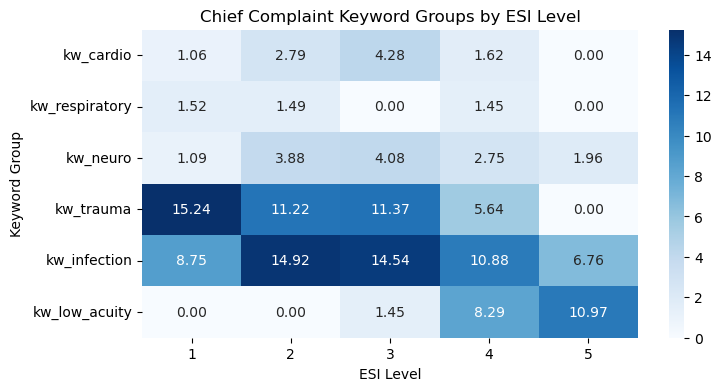

In [63]:
plt.figure(figsize=(8, 4))

sns.heatmap(
    keyword_by_esi.T,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Chief Complaint Keyword Groups by ESI Level")
plt.xlabel("ESI Level")
plt.ylabel("Keyword Group")
plt.show()

**Findings:** Chief complaint text is complete, with no missing values, but it is highly repetitive: only 4,949 unique complaints appear in 80,000 rows, meaning 93.81% of records reuse an existing complaint text. Among complaints repeated at least 10 times, the mean ESI purity is 0.999 and the median purity is 1.000, meaning repeated complaint templates almost always map to a single ESI level.

**Interpretation:** The chief complaint text contains clinical signal, but it also creates a serious shortcut risk. A model may learn to memorize repeated complaint templates instead of learning generalizable clinical language. This could inflate validation performance if the same templates appear in both training and validation folds.

**Modeling implications:** Chief complaint text should be used carefully. Later modeling should compare structured-only, text-only, and structured-plus-text models. For robustness, use GroupKFold or template-based validation grouped by `chief_complaint_raw`, so identical complaint templates do not appear in both train and validation sets.

## 10. Check Feature Redundancy

### Goal

Check whether some numerical features are strongly overlapping, and identify feature groups that should be tested with ablation rather than blindly combined.

In [65]:
# Create derived cardiovascular features
train_merged["pulse_pressure"] = (
    train_merged["systolic_bp"] - train_merged["diastolic_bp"]
)

train_merged["mean_arterial_pressure"] = (
    train_merged["systolic_bp"] + 2 * train_merged["diastolic_bp"]
) / 3

train_merged["shock_index"] = (
    train_merged["heart_rate"] / train_merged["systolic_bp"]
)

In [66]:
redundancy_cols = [
    "systolic_bp",
    "diastolic_bp",
    "pulse_pressure",
    "mean_arterial_pressure",
    "heart_rate",
    "shock_index",
    "respiratory_rate",
    "spo2",
    "gcs_total",
    "news2_score",
    "pain_score_clean"
]

# Add selected clinical flags created earlier
flag_cols_for_corr = [
    "high_news2",
    "low_gcs",
    "very_low_gcs",
    "low_spo2",
    "tachypnea",
    "hypotension",
    "fever",
    "severe_pain"
]

redundancy_cols = [
    col for col in redundancy_cols + flag_cols_for_corr
    if col in train_merged.columns
]

redundancy_cols

['systolic_bp',
 'diastolic_bp',
 'pulse_pressure',
 'mean_arterial_pressure',
 'heart_rate',
 'shock_index',
 'respiratory_rate',
 'spo2',
 'gcs_total',
 'news2_score',
 'pain_score_clean',
 'high_news2',
 'low_gcs',
 'very_low_gcs',
 'low_spo2',
 'tachypnea',
 'hypotension',
 'fever',
 'severe_pain']

In [68]:
# Extract highly correlated feature pairs
corr_abs = corr_matrix.abs()

high_corr_pairs = []

for i in range(len(corr_abs.columns)):
    for j in range(i + 1, len(corr_abs.columns)):
        feature_a = corr_abs.columns[i]
        feature_b = corr_abs.columns[j]
        corr_value = corr_matrix.loc[feature_a, feature_b]
        
        if abs(corr_value) >= 0.70:
            high_corr_pairs.append({
                "feature_a": feature_a,
                "feature_b": feature_b,
                "correlation": round(corr_value, 3)
            })

high_corr_pairs = (
    pd.DataFrame(high_corr_pairs)
    .sort_values("correlation", key=lambda x: x.abs(), ascending=False)
)

high_corr_pairs

,feature_a,feature_b,correlation
14,news2_score,high_news2,0.900
18,high_news2,low_gcs,0.895
15,news2_score,low_gcs,0.865
3,diastolic_bp,mean_arterial_pressure,0.839
12,gcs_total,low_gcs,-0.832
0,systolic_bp,pulse_pressure,0.826
17,pain_score_clean,severe_pain,0.821
9,spo2,low_spo2,-0.796
7,respiratory_rate,tachypnea,0.795
5,shock_index,news2_score,0.782


In [70]:
feature_groups = pd.DataFrame([
    {
        "feature_group": "Blood pressure",
        "examples": "SBP, DBP, MAP, pulse pressure, hypotension",
        "modeling_note": "Derived from overlapping BP information"
    },
    {
        "feature_group": "NEWS2 / vitals",
        "examples": "NEWS2, high_NEWS2, RR, SpO2, HR, SBP",
        "modeling_note": "NEWS2 summarizes several vital signs"
    },
    {
        "feature_group": "GCS",
        "examples": "gcs_total, low_gcs, very_low_gcs",
        "modeling_note": "Flags are thresholds of GCS"
    },
    {
        "feature_group": "Oxygenation",
        "examples": "spo2, low_spo2, very_low_spo2",
        "modeling_note": "Flags are thresholds of SpO2"
    },
    {
        "feature_group": "Pain",
        "examples": "pain_score_clean, severe_pain",
        "modeling_note": "Flag is derived from pain score"
    }
])

feature_groups

,feature_group,examples,modeling_note
0,Blood pressure,"SBP, DBP, MAP, pulse pressure, hypotension",Derived from overlapping BP information
1,NEWS2 / vitals,"NEWS2, high_NEWS2, RR, SpO2, HR, SBP",NEWS2 summarizes several vital signs
2,GCS,"gcs_total, low_gcs, very_low_gcs",Flags are thresholds of GCS
3,Oxygenation,"spo2, low_spo2, very_low_spo2",Flags are thresholds of SpO2
4,Pain,"pain_score_clean, severe_pain",Flag is derived from pain score


**Findings:** Several feature groups are highly redundant. `news2_score` is strongly correlated with `high_news2` (0.900), `low_gcs` (0.865), respiratory rate (0.729), SpO2 (-0.729), and tachypnea (0.717). Threshold flags are also strongly tied to their source variables, such as `gcs_total` with `low_gcs` (-0.832), `spo2` with `low_spo2` (-0.796), `respiratory_rate` with `tachypnea` (0.795), and `pain_score_clean` with `severe_pain` (0.821). Blood-pressure-derived variables also overlap strongly with raw BP features.

**Interpretation:** These features are not independent evidence. NEWS2 summarizes multiple vital signs, and clinical flags are thresholded versions of raw measurements. This redundancy is expected and clinically meaningful, but it may inflate feature importance or create multicollinearity in simpler models.

**Modeling implications:** Keep raw vitals, NEWS2, and clinical flags for initial tree-based models, but run ablation studies to compare: raw vitals only, raw vitals + NEWS2, raw vitals + flags, and all structured features. For linear models, avoid using all redundant variables without regularization.

## 11. Check Nurse and Site Variability

### Goal

Check whether different sites or triage nurses show systematically different ESI distributions. This is useful for workflow audit, fairness analysis, and deciding whether operational variables should be used as model features.

In [78]:
# ESI distribution by site
site_esi = (
    pd.crosstab(
        train_merged["site_id"],
        train_merged["triage_acuity"],
        normalize="index"
    ) * 100
).round(2)

site_esi

triage_acuity,1,2,3,4,5
site_id,,,,,
SITE-HEL-01,4.17,16.70,35.57,29.52,14.04
SITE-HEL-02,3.94,16.67,36.10,28.83,14.45
SITE-OUL-01,3.98,16.58,36.69,28.40,14.35
SITE-TMP-01,3.97,16.84,36.18,28.62,14.39
SITE-TUR-01,4.07,17.20,36.23,28.49,14.01


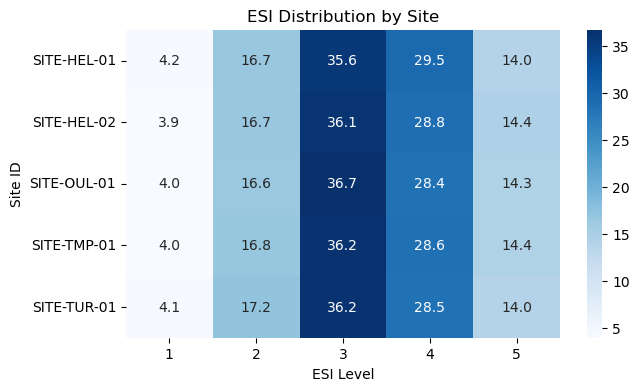

In [79]:
plt.figure(figsize=(7, 4))

sns.heatmap(
    site_esi,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("ESI Distribution by Site")
plt.xlabel("ESI Level")
plt.ylabel("Site ID")
plt.show()

In [80]:
# Nurse-level ESI summary
nurse_summary = (
    train_merged
    .groupby("triage_nurse_id")["triage_acuity"]
    .agg(
        n_cases="count",
        mean_esi="mean",
        esi1_rate=lambda x: (x == 1).mean() * 100,
        high_acuity_rate=lambda x: x.isin([1, 2]).mean() * 100
    )
    .round(2)
    .sort_values("high_acuity_rate", ascending=False)
)

nurse_summary.head(10)

,n_cases,mean_esi,esi1_rate,high_acuity_rate
triage_nurse_id,,,,
NURSE-0022,1578,3.27,4.50,23.32
NURSE-0019,1656,3.29,4.83,22.28
NURSE-0008,1543,3.29,4.47,22.23
NURSE-0014,1587,3.29,4.79,22.12
NURSE-0032,1621,3.28,4.57,21.90
NURSE-0010,1680,3.33,3.81,21.85
NURSE-0016,1559,3.33,3.66,21.62
NURSE-0036,1551,3.30,4.64,21.60
NURSE-0026,1632,3.31,4.90,21.51


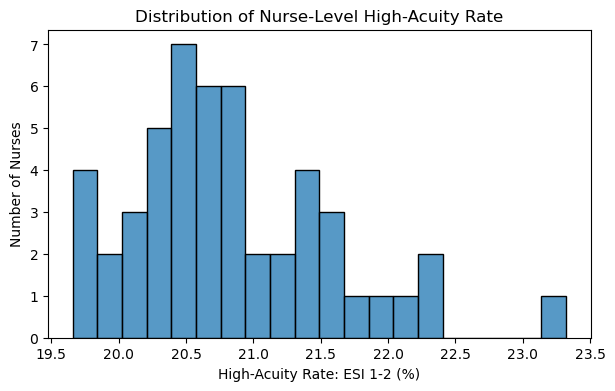

In [81]:
plt.figure(figsize=(7, 4))

sns.histplot(
    data=nurse_summary,
    x="high_acuity_rate",
    bins=20
)

plt.title("Distribution of Nurse-Level High-Acuity Rate")
plt.xlabel("High-Acuity Rate: ESI 1-2 (%)")
plt.ylabel("Number of Nurses")
plt.show()

**Findings:** Site-level ESI distributions are almost identical across the five sites. ESI-1 rates stay around 3.94–4.17%, and high-acuity patterns are very similar across sites. Nurse-level high-acuity rates show some variation, roughly ranging from about 19.7% to 23.3%, but most nurses cluster around 20–21.5%.

**Interpretation:** There is no strong evidence of major site-level triage distribution shift in this dataset. Nurse-level variation exists, but the range is modest and may reflect case mix, workflow assignment, or provider practice rather than bias alone.

**Modeling implications:** `site_id` is unlikely to be a major predictive signal based on distribution alone. `triage_nurse_id` should be used cautiously: it may improve validation performance, but it risks encoding provider-specific behavior rather than generalizable patient severity.

## 12. Check Comorbidity Burden

### Goal

Check whether patients with more recorded medical history or comorbidities tend to receive higher-acuity ESI levels.

In [89]:
# Select binary patient history columns
history_cols = [col for col in history.columns if col != "patient_id"]

binary_history_cols = []

for col in history_cols:
    values = set(history[col].dropna().unique())
    if values.issubset({0, 1, False, True}):
        binary_history_cols.append(col)

# Create comorbidity burden as the number of positive history flags
train_merged["comorbidity_count"] = (
    train_merged[binary_history_cols]
    .fillna(0)
    .astype(int)
    .sum(axis=1)
)

print("Number of binary history columns:", len(binary_history_cols))

Number of binary history columns: 25


In [90]:
comorbidity_by_esi = (
    train_merged
    .groupby("triage_acuity")["comorbidity_count"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

comorbidity_by_esi

,count,mean,median,min,max
triage_acuity,,,,,
1,3222,6.62,6.0,0,19
2,13439,6.48,6.0,0,20
3,28921,5.05,5.0,0,17
4,23020,5.05,5.0,0,17
5,11398,5.02,5.0,0,17


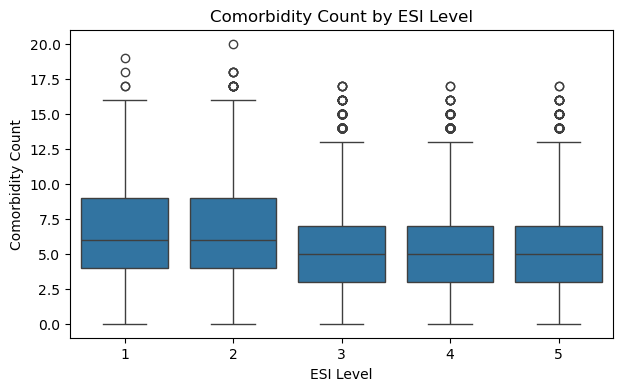

Mutual information of comorbidity_count with ESI: 0.0208


In [91]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=train_merged,
    x="triage_acuity",
    y="comorbidity_count"
)

plt.title("Comorbidity Count by ESI Level")
plt.xlabel("ESI Level")
plt.ylabel("Comorbidity Count")
plt.show()

from sklearn.feature_selection import mutual_info_classif

mi_comorbidity = mutual_info_classif(
    train_merged[["comorbidity_count"]],
    train_merged["triage_acuity"],
    random_state=42
)[0]

print(f"Mutual information of comorbidity_count with ESI: {mi_comorbidity:.4f}")

**Findings:** All 25 patient history columns are binary comorbidity flags. Comorbidity burden is slightly higher in ESI-1 and ESI-2 patients, with mean counts of 6.62 and 6.48, compared with about 5.02–5.05 for ESI-3 to ESI-5. However, the mutual information between `comorbidity_count` and ESI is low (0.0208).

**Interpretation:** Patient history provides some background risk context, but it is much weaker than acute physiological features such as NEWS2, GCS, SpO2, respiratory rate, and pain score.

**Modeling implications:** `comorbidity_count` can be added as a secondary structured feature, but it should not be expected to drive model performance. Later ablation should test whether patient history adds value beyond acute vitals and chief complaint text.

## 13. Final EDA Findings and Modeling Decisions

### Key modeling decisions

| Area | Key finding | Modeling decision |
|---|---|---|
| Data structure | All `patient_id` values are unique; auxiliary tables merge without duplicating rows. | Use the merged train/test tables for EDA and modeling. |
| Leakage | `ed_los_hours` and `disposition` are train-only post-triage outcomes. | Exclude both from model features. |
| Target | ESI-1 is rare (4.03%); high-acuity ESI 1-2 cases are 20.83%. | Use Macro F1, Weighted Kappa, ESI-1/2 recall, and dangerous undertriage metrics. |
| Missingness | Vital sign missingness appears mainly in ESI 4-5; `pain_score = -1` appears only in ESI 3-5. | Add missing indicators and treat `pain_score = -1` as a special missing code. |
| Numerical vitals | NEWS2, GCS, pain score, SpO2, and respiratory rate are the strongest numerical signals. | Retain core vitals and use `pain_score_clean` instead of raw `pain_score`. |
| Clinical flags | High-risk flags are concentrated in ESI 1-2 and mostly disappear in ESI 4-5. | Use clinical flags as interpretable engineered features, but test with ablation. |
| Categorical features | `mental_status_triage` is informative; `arrival_mode` and broad complaint system are less discriminative. | Keep `mental_status_triage`; use operational variables cautiously. |
| Chief complaint text | Text is complete but highly repetitive; 93.81% of rows reuse existing complaint text. | Compare structured-only, text-only, and combined models. |
| Text shortcut risk | Repeated complaint templates have near-perfect ESI purity. | Use GroupKFold by `chief_complaint_raw` to test robustness. |
| Feature redundancy | NEWS2, raw vitals, derived features, and clinical flags overlap strongly. | Run ablation studies instead of treating all features as independent evidence. |
| Nurse/site variability | Site-level ESI distributions are almost identical; nurse-level high-acuity rates vary modestly. | Use `site_id` and `triage_nurse_id` mainly for audit or ablation, not as core clinical predictors. |
| Patient history | Comorbidity count is slightly higher in ESI-1/2, but its mutual information is low (0.0208). | Use `comorbidity_count` as a secondary context feature and test its added value with ablation. |

### Recommended feature sets

| Feature set | Include | Exclude | Purpose |
|---|---|---|---|
| Structured baseline | Raw vitals, demographics, categorical intake variables, and patient history summary | Leakage columns, `patient_id` | Main baseline model |
| Structured + clinical flags | Structured baseline + clinical risk flags | Leakage columns | Test whether interpretable flags improve performance |
| Structured without NEWS2 | Raw vitals and categorical variables, excluding NEWS2 | NEWS2, leakage columns | Check whether NEWS2 adds value beyond raw vitals |
| Text-only | `chief_complaint_raw` | Structured clinical variables | Measure text signal and shortcut risk |
| Structured + text | Structured features + chief complaint text | Leakage columns | Final combined proof-of-concept model |

### Recommended validation plan

| Validation setup | Purpose | Risk addressed |
|---|---|---|
| Random stratified split | Basic baseline validation | Standard performance estimate |
| GroupKFold by `chief_complaint_raw` | Test robustness to unseen complaint templates | Repeated-text shortcut risk |
| With vs without NEWS2 | Check whether NEWS2 adds value beyond raw vitals | NEWS2 may dominate because it summarizes several vitals |
| With vs without clinical flags | Check whether threshold flags add useful interpretability or performance | Flags may duplicate raw vitals |
| With vs without patient history | Check whether comorbidity context adds value beyond acute vitals | Patient history may be weaker than acute physiological signals |
| High-acuity safety evaluation | Measure ESI-1/2 recall and dangerous undertriage | Accuracy may hide unsafe errors |

### Final summary

This EDA shows that the dataset is structurally clean after merging, but several modeling risks need to be handled carefully. `ed_los_hours` and `disposition` are leakage features and must be excluded. The target is imbalanced and ordinal, so evaluation should focus on Macro F1, Weighted Kappa, ESI-1/2 recall, and dangerous undertriage rather than accuracy alone.

The strongest structured signals come from acute clinical severity variables such as NEWS2, GCS, SpO2, respiratory rate, pain score, mental status, and clinical risk flags. Patient history provides additional background context, but it is much weaker than acute physiological features. Site-level variation is minimal, while nurse-level variation should be treated as a workflow audit signal rather than a purely clinical predictor.

Chief complaint text is complete and potentially useful, but it is highly repetitive. Repeated complaint templates almost perfectly map to ESI labels, so text-based validation may overestimate generalization if identical templates appear in both train and validation sets. Therefore, any text model should be evaluated with grouped validation by `chief_complaint_raw`.

### Recommended next step

Build a structured baseline first, excluding leakage columns. Then compare models with and without NEWS2, with and without clinical flags, and with and without patient history. Finally, add chief complaint text and evaluate the final model using both random stratified validation and GroupKFold by complaint text.